# Welcome to the synchronization validation code
A quick note that if the delay between computers is 1 second (which would be quite good actually), then there is atleast a delay of one times the sample rate (1e6) hence the stepsize should be in this order for the first analysis. The way in which this code should be used is using the following steps
- Load the shortened files from noise tests
- Perform the first analysis to detect the different relative delays
- slice the data accordingly
- perform the second analysis to detect any shift in delay

# prior parameter

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal
from scipy.optimize import curve_fit
import os

from data import read_file, save_file, create_smaller_copy

# samples per second
sample_rate=2.5e6 

# listing filenames and type

In [2]:
# specify data type
data_type = np.float32

# the filenames for the different signals
file_names = ["20252111_17_25_antenna_1.dat", 
              "2025_21_11_17_25_antenna_3.dat",
              "20251121-1725-ant-4",
              "20251121-1725-ant-5",
              "21_nov_observation_17_25_6",
              "21_nov_observation_17_25_7",
              "21_november-17_25-airspy8",
              "2025_21_11_17_25_antenna_9.dat"]

# Loading and cutting data

In [3]:
# the starting sample in the data, to atleast throw away some unreliable starting data
start_sample=0

base_dir = "/data2/Radio Astronomy 2025/Data 21-11/"

data = {}
for name in file_names:
    data[name] = read_file(os.path.join(base_dir, name), chunks=10, chunk_size=int(sample_rate), dtype=data_type, start_idx=int(start_sample))


┌──────────────────────────────────────────────────────────────────────────────────────────┐
│ File: /data2/Radio Astronomy 2025/Data 21-11/20252111_17_25_antenna_1.dat                │
│ Total samples: 2,263,377,920                                                             │
│ Starting at index: 0                                                                     │
│ Available samples: 2,263,377,920                                                         │
│ Requested samples: 25,000,000                                                            │
│ Reading 10 full chunks of size 2,500,000 samples each                                    │
└──────────────────────────────────────────────────────────────────────────────────────────┘


Reading chunks: 100%|██████████| 10/10 [00:00<00:00, 63453.92it/s]

┌──────────────────────────────────────────────────────────────────────────────────────────┐
│ Finished reading.                                                                        │
│ Chunks requested: 10                                                                     │
│ Chunks actually read: 10                                                                 │
│ Total samples read: 25,000,000                                                           │
│ Last index: 25,000,000                                                                   │
└──────────────────────────────────────────────────────────────────────────────────────────┘

┌──────────────────────────────────────────────────────────────────────────────────────────┐
│ File: /data2/Radio Astronomy 2025/Data 21-11/2025_21_11_17_25_antenna_3.dat              │
│ Total samples: 2,561,207,296                                                             │
│ Starting at index: 0                                               

Reading chunks: 100%|██████████| 10/10 [00:00<00:00, 73843.38it/s]


┌──────────────────────────────────────────────────────────────────────────────────────────┐
│ Finished reading.                                                                        │
│ Chunks requested: 10                                                                     │
│ Chunks actually read: 10                                                                 │
│ Total samples read: 25,000,000                                                           │
│ Last index: 25,000,000                                                                   │
└──────────────────────────────────────────────────────────────────────────────────────────┘


...

Reading chunks: 100%|██████████| 10/10 [00:00<00:00, 64428.63it/s]



┌──────────────────────────────────────────────────────────────────────────────────────────┐
│ Finished reading.                                                                        │
│ Chunks requested: 10                                                                     │
│ Chunks actually read: 10                                                                 │
│ Total samples read: 25,000,000                                                           │
│ Last index: 25,000,000                                                                   │
└──────────────────────────────────────────────────────────────────────────────────────────┘

┌──────────────────────────────────────────────────────────────────────────────────────────┐
│ File: /data2/Radio Astronomy 2025/Data 21-11/21_nov_observation_17_25_7                  │
│ Total samples: 882,375,680                                                               │
│ Starting at index: 0                                              

Reading chunks: 100%|██████████| 10/10 [00:00<00:00, 45639.87it/s]



┌──────────────────────────────────────────────────────────────────────────────────────────┐
│ Finished reading.                                                                        │
│ Chunks requested: 10                                                                     │
│ Chunks actually read: 10                                                                 │
│ Total samples read: 25,000,000                                                           │
│ Last index: 25,000,000                                                                   │
└──────────────────────────────────────────────────────────────────────────────────────────┘


FileNotFoundError: [Errno 2] No such file or directory: '/data2/Radio Astronomy 2025/Data 21-11/21_november-17_25-airspy8'

Code to convert to complex valued signal !!for testing code only!!

In [4]:
def make_complex_nyquist_timeseries(real_timeseries):
    n           = real_timeseries.shape[0]//2   # Number of complex samples
    cos_samples = real_timeseries[0:2*n:2] # FILL_IN
    sin_samples = real_timeseries[1:2*n:2] # FILL_IN
    wave = (-1)**np.arange(n)
    return (cos_samples - 1j*sin_samples)*wave

#complex_1 = make_complex_nyquist_timeseries(data[file_names[0]][:int(10e4)])
#complex_2 = make_complex_nyquist_timeseries(data[file_names[1]][:int(10e4)])

# First Analysis

function to do a first correlation analysis

In [5]:
def first_correlation_analysis(file1, file2, sample_step_size, corr_mode='same', plot_x_division=4):
    signal1 = data[file1][:int(sample_step_size)]
    signal2 = data[file2][:int(sample_step_size)]

    print(len(signal1))

    auto_correlate=scipy.signal.correlate(signal1, signal1, mode=corr_mode)/signal1.shape[0]
    correlate=scipy.signal.correlate(signal1, signal2, mode=corr_mode)/signal1.shape[0]

    # Create 2 arrays of ones with the same length as the signals
    ones1 = np.ones_like(signal1)
    ones2 = np.ones_like(signal2)

    # Correlate the two arrays of ones to get the normalization factor
    norm_factor = scipy.signal.correlate(ones1, ones2, mode=corr_mode)

    # Normalize the cross-correlation
    correlate /= norm_factor
    auto_correlate /= norm_factor

    x_axis=np.arange(0,len(correlate),1)
    x_length = len(x_axis)
    x_middle = x_length/2

    index_max=np.argmax(abs(correlate))
    delta_x=index_max-x_middle
    print(f'cross-correlate shows delay of {delta_x} between {file1} and {file2}')

    """The rest is just plotting!"""
    fig, ax = plt.subplots(1,2)
    fig.suptitle(f"Autocorrelation of {file1} and correlation between {file1} and {file2}", fontsize=10)
    ax[0].plot(x_axis, np.abs(auto_correlate))
    ax[1].plot(x_axis, np.abs(correlate))

    ax[0].axvline(x=len(x_axis)/2, color='grey', linestyle=':', linewidth=1)
    ax[0].set_title("Autocorrelation")
    ax[0].set_xlabel("Delay (samples)", fontsize=13)
    ax[0].set_ylabel("Value", fontsize=13)
    for axis in 'left', 'bottom','right','top':
        ax[0].spines[axis].set_linewidth(1.5)
        ax[1].spines[axis].set_linewidth(1.5)
        ax[0].tick_params(axis='both', which='major', labelsize=13, width=1.5, length=6)

    ax[1].set_xlim(x_middle - x_length/plot_x_division, x_middle + x_length/plot_x_division)
    ax[1].axvline(x=len(x_axis)/2, color='grey', linestyle=':', linewidth=1)
    ax[1].set_title("Crosscorrelation")
    ax[1].set_xlabel("Delay (samples)", fontsize=13)
    ax[1].tick_params(axis='both', which='major', labelsize=13, width=1.5, length=6)

    plt.savefig(f"cross-correlation file {file1} and file {file2}.pdf")

run first analysis for files

10000000
cross-correlate shows delay of 696556.0 between 21_november-17_10-airspy8 and 2025_21_11_17_10_antenna_3.dat
correlation has been done for 2025_21_11_17_10_antenna_3.dat
10000000
cross-correlate shows delay of 4205562.0 between 21_november-17_10-airspy8 and 20251121-1710-ant-4
correlation has been done for 20251121-1710-ant-4
10000000
cross-correlate shows delay of -4539736.0 between 21_november-17_10-airspy8 and 20251121-1710-ant-5
correlation has been done for 20251121-1710-ant-5
10000000
cross-correlate shows delay of -4127116.0 between 21_november-17_10-airspy8 and 21_nov_observation_17_10_6
correlation has been done for 21_nov_observation_17_10_6
10000000
cross-correlate shows delay of -4808850.0 between 21_november-17_10-airspy8 and 21_nov_observation_17_10_7
correlation has been done for 21_nov_observation_17_10_7
10000000
cross-correlate shows delay of 0.0 between 21_november-17_10-airspy8 and 21_november-17_10-airspy8
correlation has been done for 21_november-17_10-ai

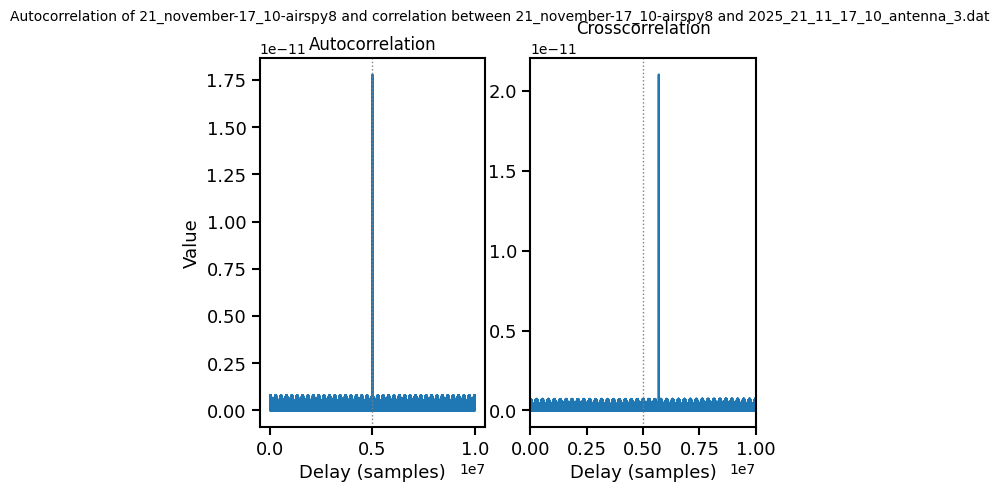

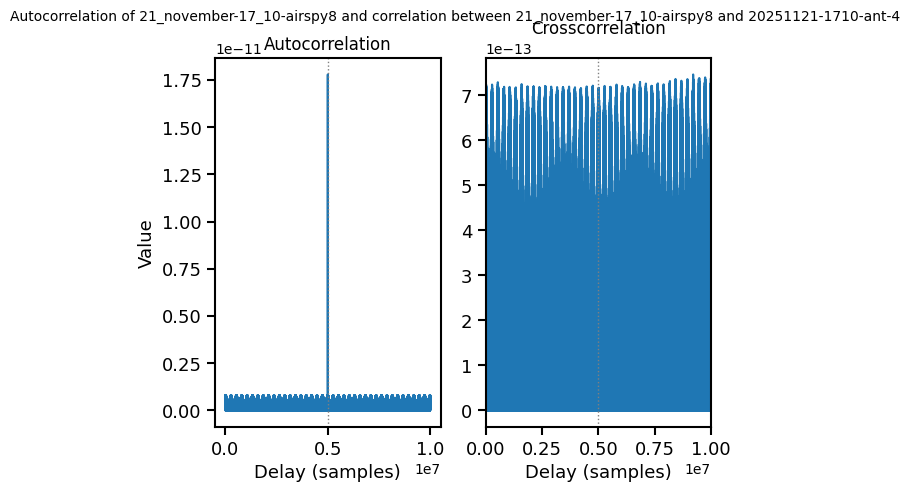

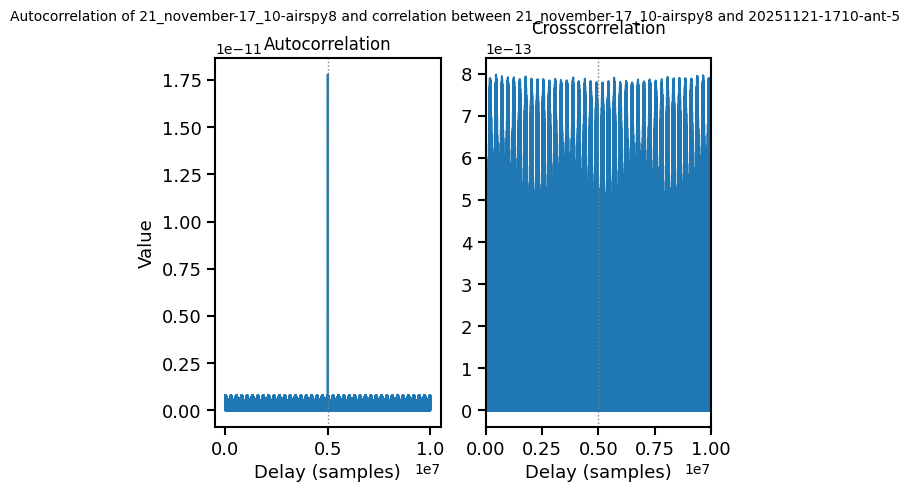

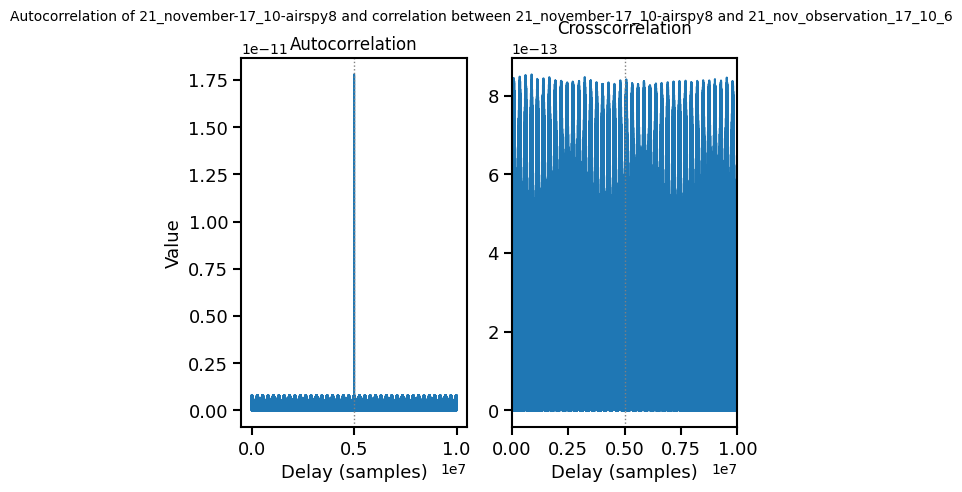

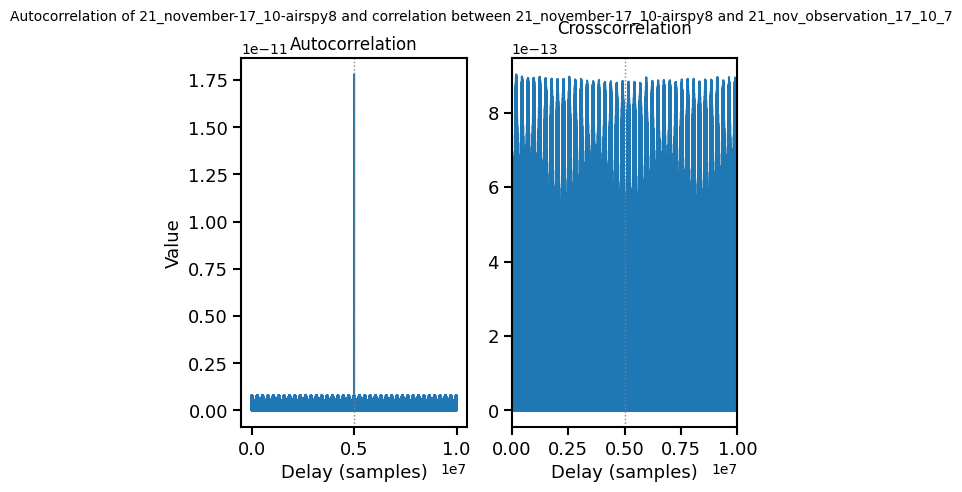

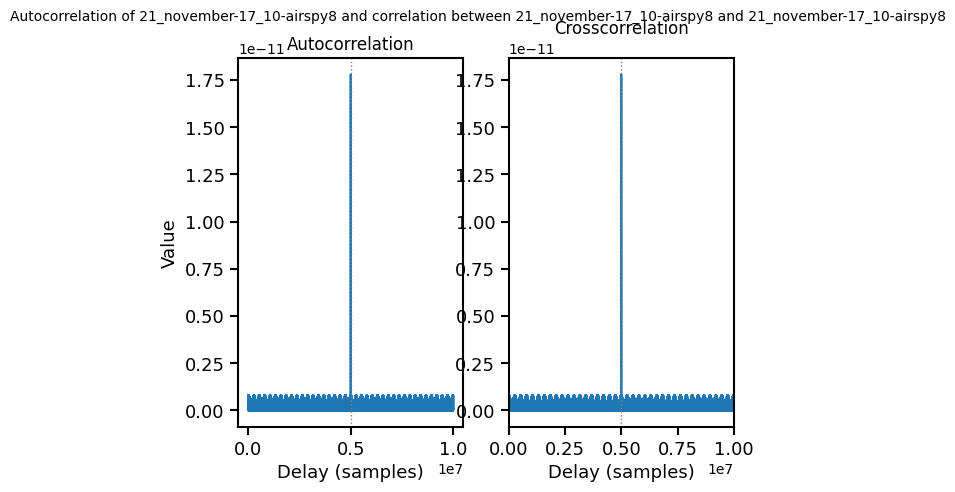

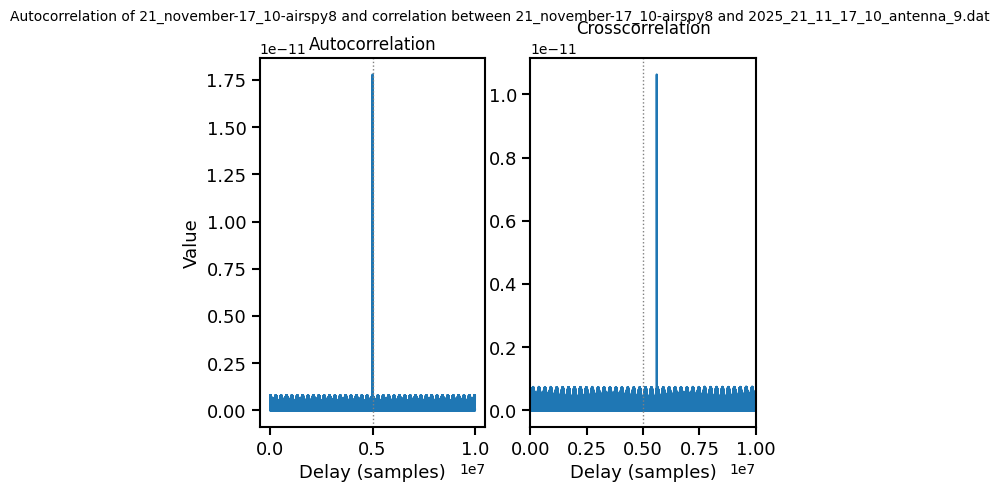

In [10]:
for name in file_names:
    first_correlation_analysis(file_names[5], name, sample_step_size=10e6, plot_x_division=2)
    print(f'correlation has been done for {name}')

# Second analysis - phase diagrams

shift the data

In [7]:
data_cut = data.copy()

"""fill in delays here and define the new files below"""
#delay_i0 = 
delay_i3 = 696556
delay_i9 = 604052

# 8 - 3 696556.0
# 8 - 9 604052.0


# data_cut[file_names[0]] = data[file_names[0]][delay_i3:]
# data_cut[file_names[-1]] = data[file_names[-1]][delay_i9:]

The function for second analyses

In [8]:
# define a line funcion to fit
def func_line(x,a,b):
    return a*x+b

def delay_diagrams(file1, file2, amount_steps=200, sample_step_size=10e4, corr_mode='same'):
    signal1 = data_cut[file1]
    signal2 = data_cut[file2]
    print(f" received {file1} of length {len(signal1)}")
    print(f" received {file2} of length {len(signal2)}")

    middle=sample_step_size/2
    sample_shift=np.zeros(amount_steps)

    
    """Itterating over the different sections of the data for correlation"""
    for i in range(amount_steps):
        signal1_cut=signal1[int(start_sample+(i*sample_step_size)):int(start_sample+((i+1)*sample_step_size))] 
        signal2_cut=signal2[int(start_sample+(i*sample_step_size)):int(start_sample+((i+1)*sample_step_size))]

        correlate=scipy.signal.correlate(signal1_cut, signal2_cut, mode=corr_mode)/signal1_cut.shape[0]

        x=np.arange(0,len(correlate),1)
        index_max=np.argmax(abs(correlate))
        delta_x=index_max-middle
        sample_shift[i]=index_max-middle

        if i % 10 == 0:
            print(f'itteration {i} done')


    """Performing a linear fit to the data"""
    sample_array=np.arange(0, amount_steps,1)
    popt, pcov = curve_fit(func_line,sample_array,sample_shift)
    x_fit=np.linspace(np.min(sample_array),np.max(sample_array),1000)
    y_fit=func_line(x_fit,popt[0],popt[1])


    """plotting"""
    plt.scatter(sample_array,sample_shift,color="red",label="Delay samples")
    plt.plot(x_fit,y_fit,color="black",label="fit")
    plt.xlabel("Amount of steps (each step="+(f'{sample_step_size:.3g}')+" samples)")
    plt.ylabel("Delay (samples)")
    plt.title(f"Delay shift of signals from {file1} and {file2}")
    plt.ticklabel_format(useOffset=False)
    plt.legend()
    # plt.savefig("zero_delay.pdf",bbox_inches="tight")
    plt.grid()
    plt.show()
    print("slope="+str(popt[0])+" b="+str(popt[1]))



calling the function

In [15]:
delay_diagrams(file_names[0], file_names[-1])

KeyError: '2025_21_11_17_25_antenna_9.dat'